In [ ]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


# Data Augmentation Experiment — M7md's Branch

This notebook studies the effect of **data augmentation** as a regularization
technique on the overfitting MLP baseline trained on CIFAR-10.

### Augmentation Techniques Applied (training data only)
- `RandomHorizontalFlip`
- `RandomCrop(32, padding=4)`
- `ColorJitter(brightness=0.2, contrast=0.2)`

### Controlled Setup (identical to all other team experiments)
| Parameter | Value |
|-----------|-------|
| Model | MLP [1024, 512, 256] with ReLU |
| Optimizer | SGD, lr = 0.01 |
| Epochs | 50 |
| Batch size | 128 |
| Train / Val / Test | 15 000 / 5 000 / 10 000 |
| Seed | 42 |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## Model Definition

In [2]:
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False,
                 dropout_p=0.5, hidden_sizes=None):
        super(AblationMLP, self).__init__()
        if hidden_sizes is None:
            hidden_sizes = [1024, 512, 256]

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3072, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0]) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1]) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2]) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc4 = nn.Linear(hidden_sizes[2], 10)

        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:
            x = self.dropout1(x)

        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:
            x = self.dropout2(x)

        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:
            x = self.dropout3(x)

        x = self.fc4(x)
        return x

## Helper Functions

In [3]:
def evaluate(model, dataloader, device):
    """Compute accuracy on a dataloader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    return 100 * correct / total


def compute_loss(model, dataloader, loss_fn, device):
    """Compute average loss on a dataloader."""
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
    model.train()
    return total_loss / len(dataloader)


def train_epoch(model, train_loader, optimizer, loss_fn, device):
    """Train for one epoch and return average loss."""
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

## Data Loading — WITH Augmentation for Training

Data augmentation is applied **only** to the training set.
Validation and test sets use standard normalization.

In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

# Augmented transform — applied ONLY to training data
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Standard transform — for validation and test data
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Load CIFAR-10 — two copies of training set (augmented + standard)
full_train_augmented = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
full_train_standard  = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=eval_transform)
full_test_dataset    = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=eval_transform)

# 3-Way Split (Golden Rule)
torch.manual_seed(SEED)
subset_size = 20000
remaining_size = 50000 - subset_size

subset_aug, _ = torch.utils.data.random_split(
    full_train_augmented, [subset_size, remaining_size],
    generator=torch.Generator().manual_seed(SEED))
subset_std, _ = torch.utils.data.random_split(
    full_train_standard, [subset_size, remaining_size],
    generator=torch.Generator().manual_seed(SEED))

train_size = 15000
val_size   = 5000

train_dataset, _ = torch.utils.data.random_split(
    subset_aug, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED))
_, val_dataset   = torch.utils.data.random_split(
    subset_std, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED))

test_dataset = full_test_dataset

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True)
val_loader   = torch.utils.data.DataLoader(
    val_dataset, batch_size=128, shuffle=False)
test_loader  = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle=False)

print("=" * 80)
print("DATA AUGMENTATION EXPERIMENT")
print("=" * 80)
print(f"Training set size:   {len(train_dataset):,} images  (with augmentation)")
print(f"Validation set size: {len(val_dataset):,} images  (no augmentation)")
print(f"Test set size:       {len(test_dataset):,} images  (no augmentation)")
print(f"Total used:          {len(train_dataset) + len(val_dataset) + len(test_dataset):,} images")
print("=" * 80)

100%|██████████| 170M/170M [00:05<00:00, 32.2MB/s]


DATA AUGMENTATION EXPERIMENT
Training set size:   15,000 images  (with augmentation)
Validation set size: 5,000 images  (no augmentation)
Test set size:       10,000 images  (no augmentation)
Total used:          30,000 images


## Model & Optimizer Setup

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 0.01
max_epochs = 50

model = AblationMLP(
    use_dropout=False, use_batchnorm=False,
    hidden_sizes=[1024, 512, 256]).to(device)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

print(f"Device: {device}")
print(f"Learning Rate: {learning_rate}")
print(f"Max Epochs: {max_epochs}")
print(f"Model: Overparameterized MLP [1024, 512, 256] — Data Augmentation")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nAugmentation Pipeline:")
print(f"  - RandomHorizontalFlip(p=0.5)")
print(f"  - RandomCrop(32, padding=4)")
print(f"  - ColorJitter(brightness=0.2, contrast=0.2)")

Device: cpu
Learning Rate: 0.01
Max Epochs: 50
Model: Overparameterized MLP [1024, 512, 256] — Data Augmentation
Total trainable parameters: 3,805,450

Augmentation Pipeline:
  - RandomHorizontalFlip(p=0.5)
  - RandomCrop(32, padding=4)
  - ColorJitter(brightness=0.2, contrast=0.2)


## Training Loop

In [6]:
train_losses = []
val_losses   = []
train_accuracies = []
val_accuracies   = []

for epoch in range(max_epochs):
    loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
    train_losses.append(loss)

    train_acc = evaluate(model, train_loader, device)
    val_loss  = compute_loss(model, val_loader, loss_fn, device)
    val_acc   = evaluate(model, val_loader, device)

    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{max_epochs} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)
print(f"Training finished at epoch: {max_epochs}/{max_epochs}")

# Final Test Evaluation
test_acc  = evaluate(model, test_loader, device)
test_loss = compute_loss(model, test_loader, loss_fn, device)

print(f"\nFINAL TEST EVALUATION (After {max_epochs} Epochs):")
print(f"\nFinal Metrics:")
print(f"  Training Accuracy:   {train_accuracies[-1]:.2f}%")
print(f"  Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"  Test Accuracy:       {test_acc:.2f}%")
generalization_gap = train_accuracies[-1] - val_accuracies[-1]
print(f"\nGeneralization Gap Analysis:")
print(f"  GENERALIZATION GAP (Train Acc - Val Acc): {generalization_gap:.2f}% ← KEY METRIC")
print(f"  (Train Acc - Test Acc): {train_accuracies[-1] - test_acc:.2f}%")
print("=" * 80)

Epoch  1/50 | Train Loss: 2.2740 | Val Loss: 2.2415 | Train Acc: 20.51% | Val Acc: 22.30%
Epoch  2/50 | Train Loss: 2.1806 | Val Loss: 2.1374 | Train Acc: 22.82% | Val Acc: 24.48%
Epoch  3/50 | Train Loss: 2.0758 | Val Loss: 2.0597 | Train Acc: 26.25% | Val Acc: 27.30%
Epoch  4/50 | Train Loss: 2.0116 | Val Loss: 2.0053 | Train Acc: 28.43% | Val Acc: 28.74%
Epoch  5/50 | Train Loss: 1.9675 | Val Loss: 1.9676 | Train Acc: 29.85% | Val Acc: 30.00%
Epoch  6/50 | Train Loss: 1.9330 | Val Loss: 1.9388 | Train Acc: 30.36% | Val Acc: 30.82%
Epoch  7/50 | Train Loss: 1.9000 | Val Loss: 1.9064 | Train Acc: 32.09% | Val Acc: 31.80%
Epoch  8/50 | Train Loss: 1.8727 | Val Loss: 1.8703 | Train Acc: 33.65% | Val Acc: 33.62%
Epoch  9/50 | Train Loss: 1.8490 | Val Loss: 1.8521 | Train Acc: 34.61% | Val Acc: 34.02%
Epoch 10/50 | Train Loss: 1.8222 | Val Loss: 1.8195 | Train Acc: 34.17% | Val Acc: 34.64%
Epoch 11/50 | Train Loss: 1.8024 | Val Loss: 1.8263 | Train Acc: 35.45% | Val Acc: 34.60%
Epoch 12/5

## Visualization

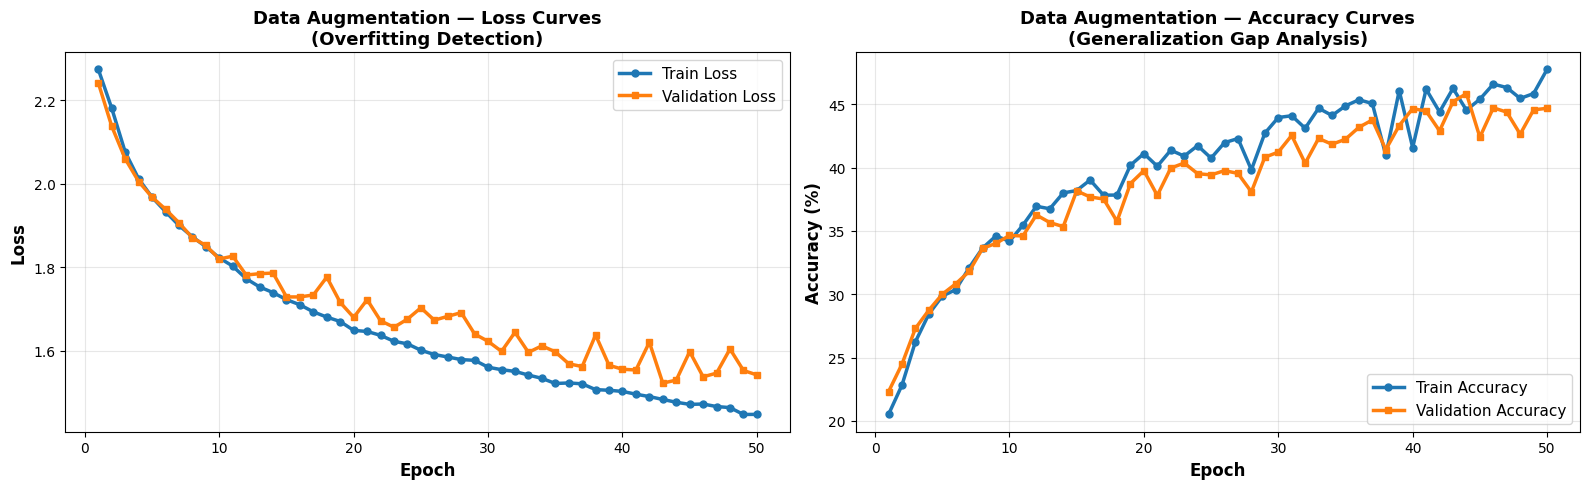


GENERALIZATION GAP SUMMARY (Data Augmentation Experiment)
Final Epoch (50):
  Training Accuracy:    47.75%
  Validation Accuracy:  44.68%
  Test Accuracy:        46.02%

GENERALIZATION GAP (Train - Val): 3.07% ← KEY METRIC FOR COMPARING REGULARIZATION METHODS


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, max_epochs + 1)

# Loss Curves
ax1.plot(epochs_range, train_losses, 'o-',
         label='Train Loss', linewidth=2.5, markersize=5, color='#1f77b4')
ax1.plot(epochs_range, val_losses, 's-',
         label='Validation Loss', linewidth=2.5, markersize=5, color='#ff7f0e')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Data Augmentation — Loss Curves\n(Overfitting Detection)',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)

# Accuracy Curves
ax2.plot(epochs_range, train_accuracies, 'o-',
         label='Train Accuracy', linewidth=2.5, markersize=5, color='#1f77b4')
ax2.plot(epochs_range, val_accuracies, 's-',
         label='Validation Accuracy', linewidth=2.5, markersize=5, color='#ff7f0e')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Data Augmentation — Accuracy Curves\n(Generalization Gap Analysis)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "=" * 80)
print("GENERALIZATION GAP SUMMARY (Data Augmentation Experiment)")
print("=" * 80)
print(f"Final Epoch ({max_epochs}):")
print(f"  Training Accuracy:    {train_accuracies[-1]:.2f}%")
print(f"  Validation Accuracy:  {val_accuracies[-1]:.2f}%")
print(f"  Test Accuracy:        {test_acc:.2f}%")
print(f"\nGENERALIZATION GAP (Train - Val): {generalization_gap:.2f}% ← KEY METRIC FOR COMPARING REGULARIZATION METHODS")
print("=" * 80)